In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import seaborn as sns
import matplotlib.pyplot as plt


## This notebook contains visualization part of the Oblig and its basically experimental (some cells can have broken code)

In [4]:
df = pd.read_csv("uci_airfoil_data.csv")
df.columns

Index(['frequency', 'attack-angle', 'chord-length', 'free-stream-velocity',
       'suction-side-displacement-thickness', 'scaled-sound-pressure'],
      dtype='str')

In [5]:
df.min(),df.max()

(frequency                              200.000000
 attack-angle                             0.000000
 chord-length                             0.025400
 free-stream-velocity                    31.700000
 suction-side-displacement-thickness      0.000401
 scaled-sound-pressure                  103.380000
 dtype: float64,
 frequency                              20000.000000
 attack-angle                              22.200000
 chord-length                               0.304800
 free-stream-velocity                      71.300000
 suction-side-displacement-thickness        0.058411
 scaled-sound-pressure                    140.987000
 dtype: float64)

In [7]:
df['chord-length'].unique()

array([0.3048, 0.2286, 0.1524, 0.0508, 0.0254, 0.1016])

In [28]:
df["chord-length"].value_counts(normalize=True).mul(100).round(2)

chord-length
0.0254    18.50
0.1524    18.03
0.2286    17.70
0.1016    17.50
0.0508    15.77
0.3048    12.51
Name: proportion, dtype: float64

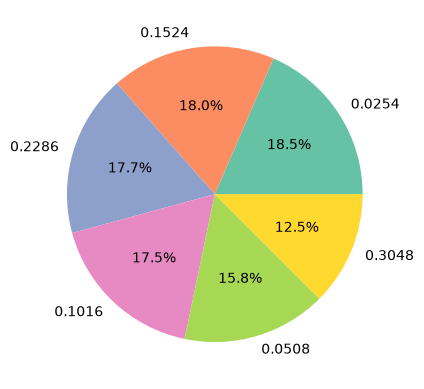

In [30]:

(df["chord-length"].value_counts(normalize=True) * 100).plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2")
)

plt.ylabel("")
plt.show()

In [20]:
sf = df[df['chord-length'] == 0.1524]
sf.shape

(271, 6)

In [43]:
df["scaled-sound-pressure"].min(), df["scaled-sound-pressure"].max()

(np.float64(103.38), np.float64(140.987))

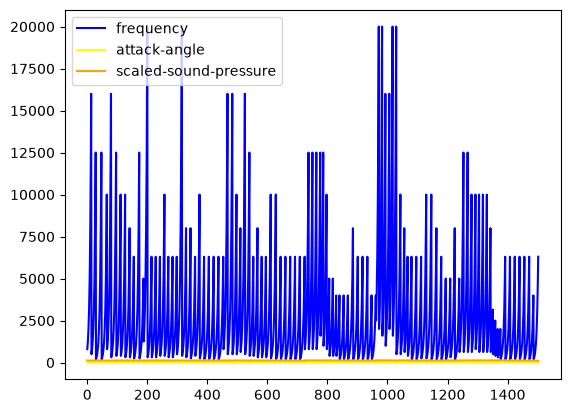

In [9]:
df[["frequency", "attack-angle", "scaled-sound-pressure"]].plot( color=["blue", "yellow", "orange"])
plt.show()

In [39]:
mf = sf[sf["attack-angle"] == 0.]

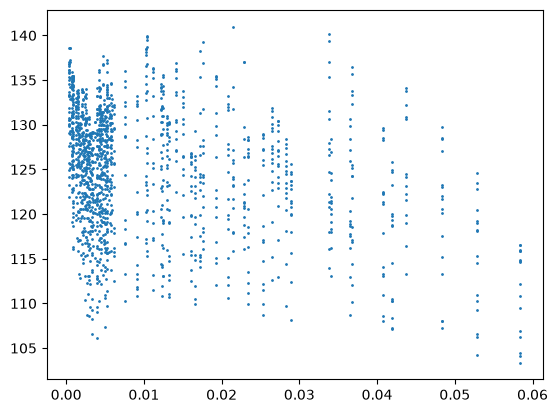

In [18]:
plt.scatter(df["suction-side-displacement-thickness"],df["scaled-sound-pressure"], label="col4", s=1)

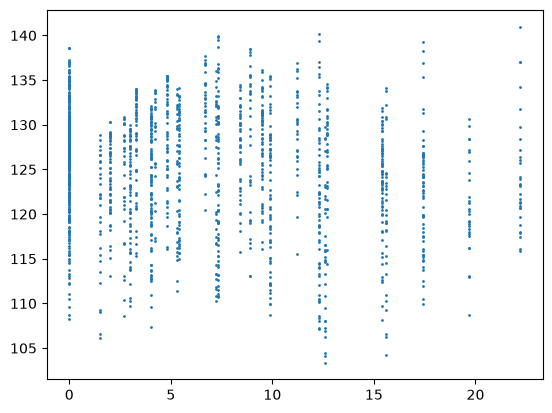

In [16]:
plt.scatter(df["attack-angle"],df["scaled-sound-pressure"], label="col2",  s=1)

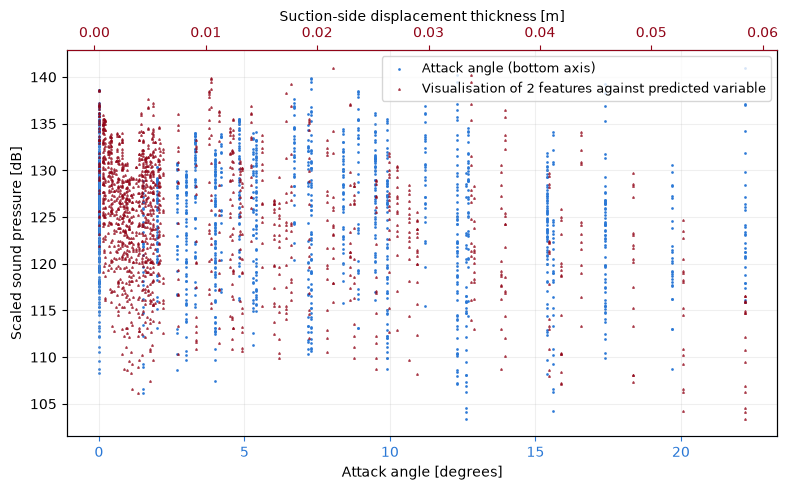

In [44]:
#plt.style.use("dark_background")
plt.style.use("default")

C1, C2 = "#2a78d6", "#910417"   

fig, ax1 = plt.subplots(figsize=(8, 5))

#  x-axis (bottom) : attack angle
ax1.scatter(df["attack-angle"], df["scaled-sound-pressure"],
            s=1, alpha=0.9, color=C1, label="Attack angle (bottom axis)")
ax1.set_xlabel("Attack angle [degrees]")
ax1.set_ylabel("Scaled sound pressure [dB]")
ax1.spines["bottom"].set_color(C1)
ax1.tick_params(axis="x", colors=C1)

# : top suction-side displacement thickness 
ax2 = ax1.twiny()
ax2.scatter(df["suction-side-displacement-thickness"], df["scaled-sound-pressure"],
            s=1, alpha=0.8, color=C2, marker="^",
            label="Visualisation of 2 features against predicted variable")
ax2.set_xlabel("Suction-side displacement thickness [m]")
ax2.spines["top"].set_color(C2)
ax2.tick_params(axis="x", colors=C2)

# Put both series in one legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=9)

ax1.grid(alpha=0.2)
fig.tight_layout()
plt.show()

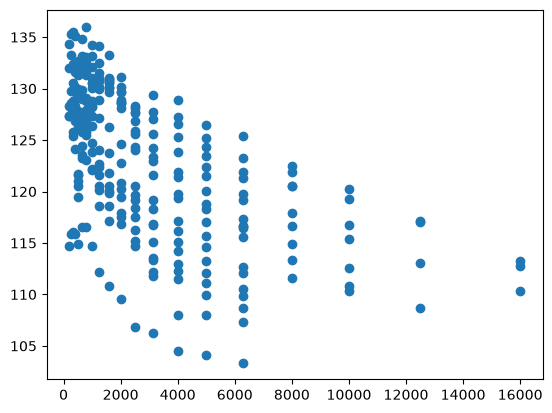

In [43]:
plt.scatter(sf["frequency"],sf["scaled-sound-pressure"] , label="col1")

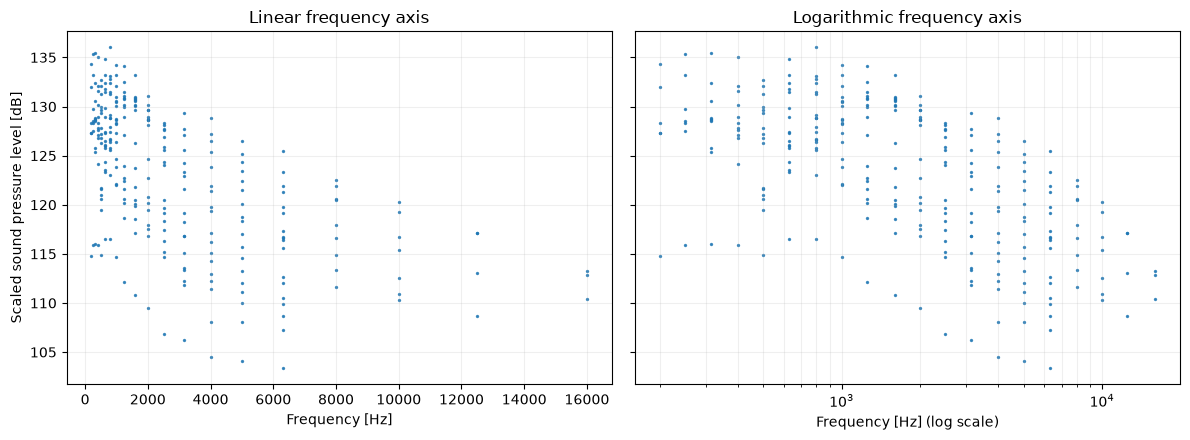

In [49]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# Linear frequency axis
ax1.scatter(sf["frequency"], sf["scaled-sound-pressure"], s=2, alpha=0.8)
ax1.set_title("Linear frequency axis")
ax1.set_xlabel("Frequency [Hz]")
ax1.set_ylabel("Scaled sound pressure level [dB]")

# Logarithmic frequency axis
ax2.scatter(sf["frequency"], sf["scaled-sound-pressure"], s=2, alpha=0.8)
ax2.set_xscale("log")
ax2.set_title("Logarithmic frequency axis")
ax2.set_xlabel("Frequency [Hz] (log scale)")

for ax in (ax1, ax2):
    ax.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.show()

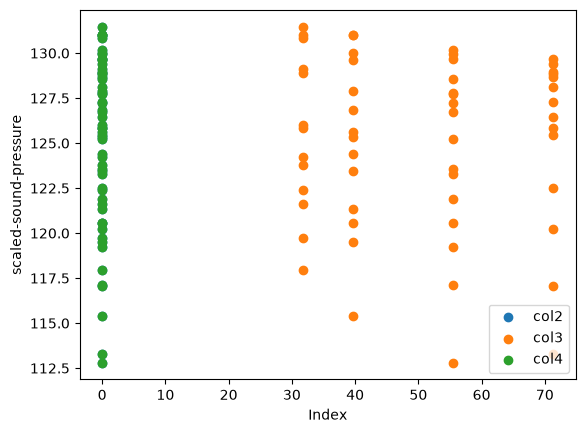

In [40]:
#plt.scatter(sf["frequency"],sf["scaled-sound-pressure"] , label="col1")
plt.scatter(mf["attack-angle"],mf["scaled-sound-pressure"], label="col2")
plt.scatter(mf["free-stream-velocity"],mf["scaled-sound-pressure"], label="col3")
plt.scatter(mf["suction-side-displacement-thickness"],mf["scaled-sound-pressure"], label="col4")


plt.legend()
plt.xlabel("Index")
plt.ylabel("scaled-sound-pressure")
plt.show()

In [10]:
plt.scatter(sf["frequency"],sf["scaled-sound-pressure"] , label="col1")
plt.scatter(sf["attack-angle"],sf["scaled-sound-pressure"], label="col2")
plt.scatter(sf["free-stream-velocity"],sf["scaled-sound-pressure"], label="col3")
plt.scatter(sf["suction-side-displacement-thickness"],sf["scaled-sound-pressure"], label="col4")


plt.legend()
plt.xlabel("Index")
plt.ylabel("scaled-sound-pressure")
plt.show()

NameError: name 'sf' is not defined

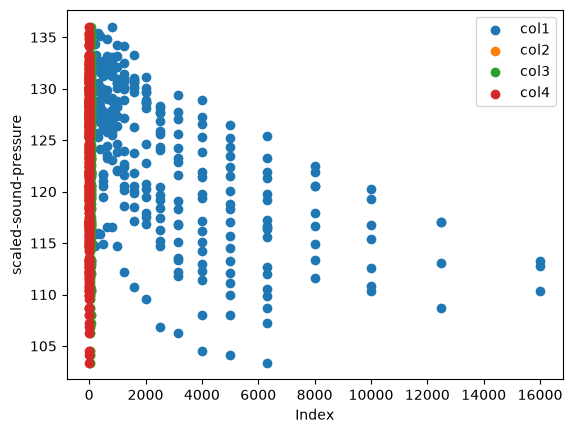

In [41]:
plt.scatter(sf["frequency"],sf["scaled-sound-pressure"] , label="col1")
plt.scatter(sf["attack-angle"],sf["scaled-sound-pressure"], label="col2")
plt.scatter(sf["free-stream-velocity"],sf["scaled-sound-pressure"], label="col3")
plt.scatter(sf["suction-side-displacement-thickness"],sf["scaled-sound-pressure"], label="col4")


plt.legend()
plt.xlabel("Index")
plt.ylabel("scaled-sound-pressure")
plt.show()

In [19]:
sf.columns

NameError: name 'sf' is not defined

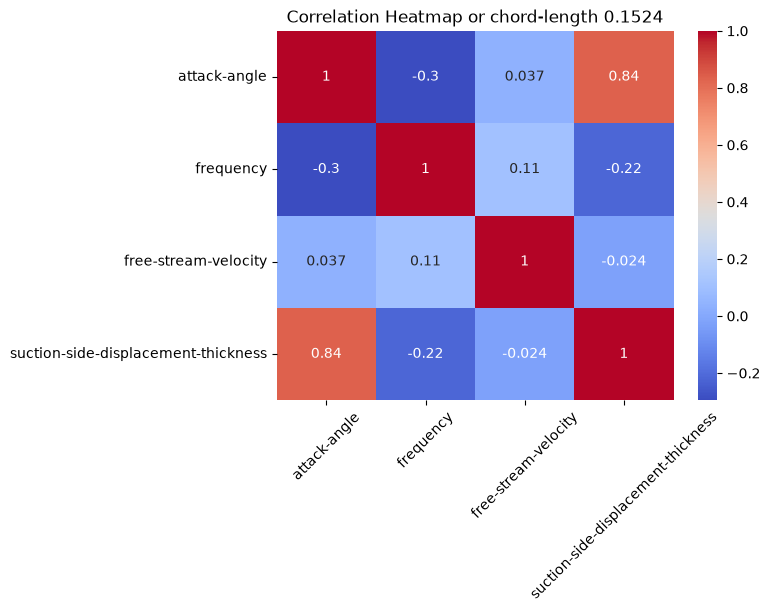

In [25]:
import seaborn as sns
mini = sf[["attack-angle", "frequency", "free-stream-velocity","suction-side-displacement-thickness"]]
corr = mini.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.xticks(rotation=45)
plt.title("Correlation Heatmap or chord-length 0.1524")
plt.show()
    #, "free-stream-velocity", ]

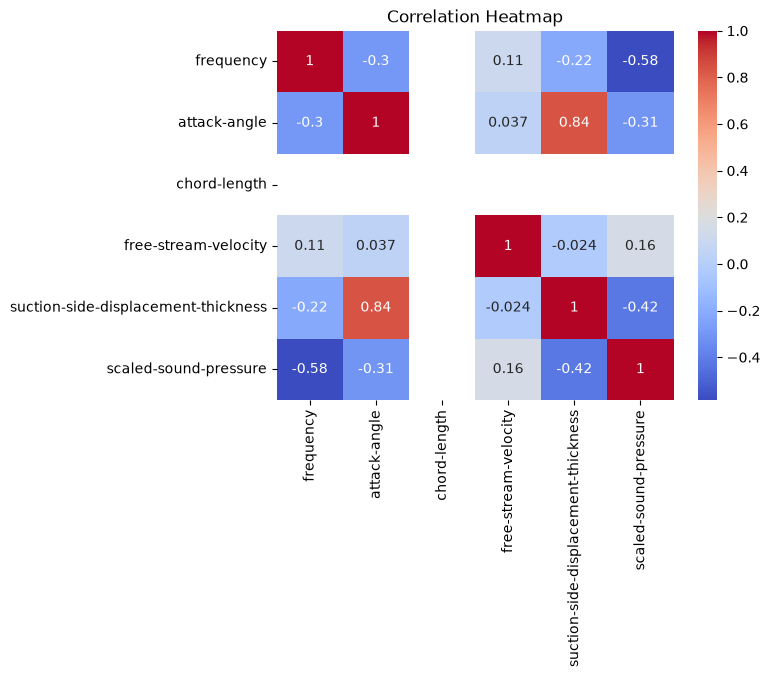

In [24]:

import matplotlib.pyplot as plt

corr = sf.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()